<a href="https://colab.research.google.com/github/AyushBanode/Projects/blob/main/zomato_cml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Zomato Analysis

## Importing the libraries

In [269]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
%matplotlib inline
import numpy as np

In [270]:
import warnings
warnings.filterwarnings('ignore')

In [271]:
data=pd.read_csv("zomato.csv", on_bad_lines='skip', engine='python')

In [272]:
data.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [273]:
data.columns

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

In [274]:
data = data.drop(['url','address','phone','menu_item',
       'listed_in(type)', 'listed_in(city)'],axis=1)

In [275]:
data.head()

,name,online_order,book_table,rate,votes,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list
0,Jalsa,Yes,Yes,4.1/5,775,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ..."
1,Spice Elephant,Yes,No,4.1/5,787,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din..."
2,San Churro Cafe,Yes,No,3.8/5,918,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ..."
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper..."
4,Grand Village,No,No,3.8/5,166,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ..."


In [276]:
data.shape

(51155, 11)

In [277]:
data.isna().sum()

,0
name,0
online_order,0
book_table,0
rate,7775
votes,0
location,21
rest_type,224
dish_liked,28074
cuisines,45
approx_cost(for two people),344


## Data cleaning

In [278]:
feature_na = [i for i in data.columns if data[i].isnull().sum() > 0]
feature_na

['rate',
 'location',
 'rest_type',
 'dish_liked',
 'cuisines',
 'approx_cost(for two people)']

In [279]:
for i in feature_na:
    print(f"{i} has {np.round((data[i].isnull().sum()/len(data[i])*100),4)}% null values")

rate has 15.1989% null values
location has 0.0411% null values
rest_type has 0.4379% null values
dish_liked has 54.8803% null values
cuisines has 0.088% null values
approx_cost(for two people) has 0.6725% null values


In [280]:
data.rate.unique()

array(['4.1/5', '3.8/5', '3.7/5', '3.6/5', '4.6/5', '4.0/5', '4.2/5',
       '3.9/5', '3.1/5', '3.0/5', '3.2/5', '3.3/5', '2.8/5', '4.4/5',
       '4.3/5', 'NEW', '2.9/5', '3.5/5', nan, '2.6/5', '3.8 /5', '3.4/5',
       '4.5/5', '2.5/5', '2.7/5', '4.7/5', '2.4/5', '2.2/5', '2.3/5',
       '3.4 /5', '-', '3.6 /5', '4.8/5', '3.9 /5', '4.2 /5', '4.0 /5',
       '4.1 /5', '3.7 /5', '3.1 /5', '2.9 /5', '3.3 /5', '2.8 /5',
       '3.5 /5', '2.7 /5', '2.5 /5', '3.2 /5', '2.6 /5', '4.5 /5',
       '4.3 /5', '4.4 /5', '4.9/5', '2.1/5', '2.0/5', '1.8/5', '4.6 /5',
       '4.9 /5', '3.0 /5', '4.8 /5', '2.3 /5', '2.4 /5', '4.7 /5',
       '2.2 /5', '2.0 /5', '2.1 /5', '1.8 /5'], dtype=object)

In [281]:
data.dropna(subset=['rate'],axis=0,inplace=True)

In [282]:
def split(x):
    return x.split('/')[0].strip()

In [283]:
data['rate'] = data['rate'].apply(split)

In [284]:
data['rate']

,rate
0,4.1
1,4.1
2,3.8
3,3.7
4,3.8
...,...
51147,3.7
51149,2.5
51150,3.6
51153,4.3


In [285]:
data.rate.unique()

array(['4.1', '3.8', '3.7', '3.6', '4.6', '4.0', '4.2', '3.9', '3.1',
       '3.0', '3.2', '3.3', '2.8', '4.4', '4.3', 'NEW', '2.9', '3.5',
       '2.6', '3.4', '4.5', '2.5', '2.7', '4.7', '2.4', '2.2', '2.3', '-',
       '4.8', '4.9', '2.1', '2.0', '1.8'], dtype=object)

In [286]:
data['rate'].replace(['NEW','-'],0,inplace=True)

In [287]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43380 entries, 0 to 51154
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         43380 non-null  object
 1   online_order                 43380 non-null  object
 2   book_table                   43380 non-null  object
 3   rate                         43380 non-null  object
 4   votes                        43380 non-null  int64 
 5   location                     43380 non-null  object
 6   rest_type                    43232 non-null  object
 7   dish_liked                   23051 non-null  object
 8   cuisines                     43369 non-null  object
 9   approx_cost(for two people)  43130 non-null  object
 10  reviews_list                 43380 non-null  object
dtypes: int64(1), object(10)
memory usage: 4.0+ MB


In [288]:
data['rate'] = data['rate'].astype(float)

In [289]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43380 entries, 0 to 51154
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         43380 non-null  object 
 1   online_order                 43380 non-null  object 
 2   book_table                   43380 non-null  object 
 3   rate                         43380 non-null  float64
 4   votes                        43380 non-null  int64  
 5   location                     43380 non-null  object 
 6   rest_type                    43232 non-null  object 
 7   dish_liked                   23051 non-null  object 
 8   cuisines                     43369 non-null  object 
 9   approx_cost(for two people)  43130 non-null  object 
 10  reviews_list                 43380 non-null  object 
dtypes: float64(1), int64(1), object(9)
memory usage: 4.0+ MB


## calculate avg rating for each restaurant

In [290]:
rating = pd.pivot_table(data,index='name',values='rate')
rating

,rate
name,
#FeelTheROLL,3.400000
#L-81 Cafe,3.900000
#refuel,3.700000
1000 B.C,3.200000
100ÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂ°C,3.700000
...,...
i-Bar - The Park Bangalore,3.800000
iFruit Live Ice Creams,3.400000
iSpice Resto Cafe,3.700000


In [291]:
rating=rating.sort_values(['rate'],ascending=False)
rating[0:15]

,rate
name,
Byg Brewski Brewing Company,4.900000
SantÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂ© Spa Cuisine,4.900000
Asia Kitchen By Mainland China,4.900000
Punjab Grill,4.866667
Flechazo,4.850000
Belgian Waffle Factory,4.844444
O.G. Variar & Sons,4.800000
The Pizza Bakery,4.800000
AB's - Absolute Barbecues,4.794118


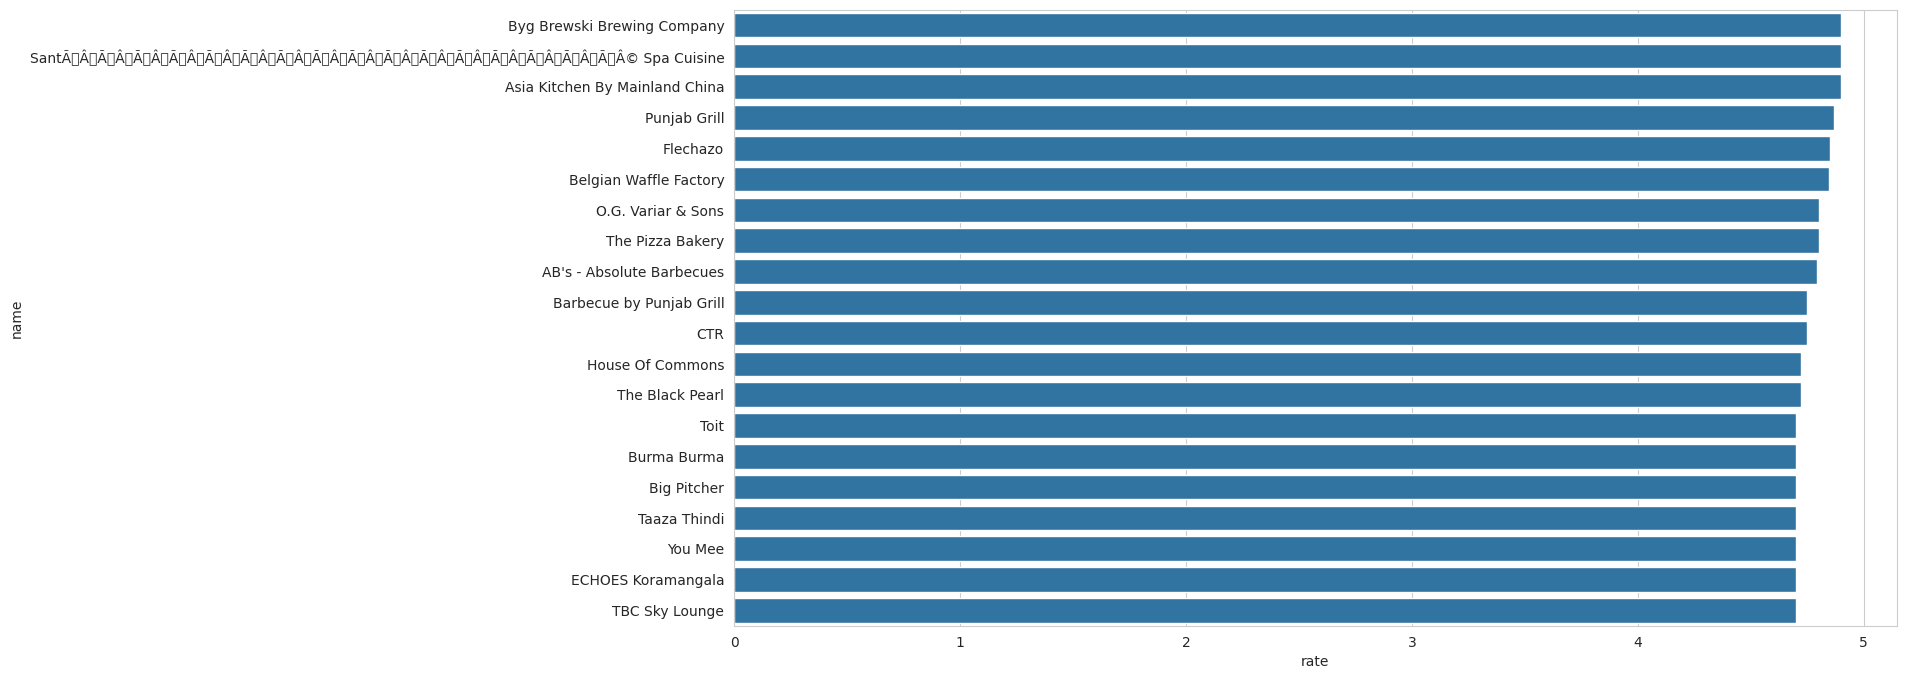

In [292]:
plt.figure(figsize=(15,8))
sns.barplot(x=rating[0:20].rate, y=rating[0:20].index, orient="h")
plt.show()

We can see that the top resturants have the highest number of average ratings

## distribution of ratings

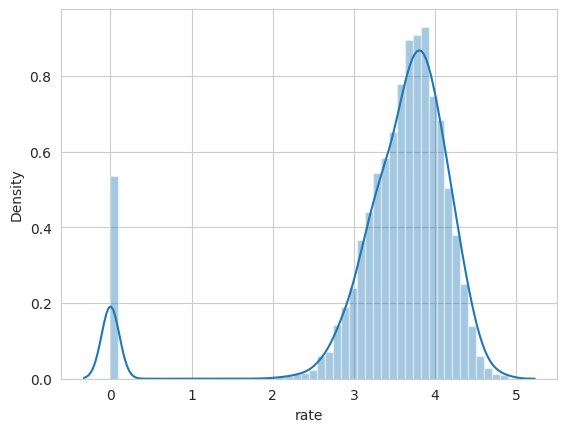

In [293]:
sns.set_style('whitegrid')
sns.distplot(data['rate'])

plt.show()

This is not a normal distibution as we can see a spike in '0's i.e the new resturants

In [294]:
from scipy.stats import normaltest

DataToTest = data['rate']

stat,p = normaltest(DataToTest)

print("stat=%0.2f,p=%0.30f" % (stat,p))

if p>0.05:
    print("Normal distribution")
else:
    print("Not a normal distribution")

stat=24315.72,p=0.000000000000000000000000000000
Not a normal distribution


## top restaurant chains

In [295]:
data['name'].value_counts()

,count
name,
Cafe Coffee Day,89
Onesta,84
Empire Restaurant,71
Kanti Sweets,68
Five Star Chicken,68
...,...
The Eatery - Four Points by Sheraton Bengaluru,1
Blend - Royal Orchid Suites,1
BBCUE Whitefield,1


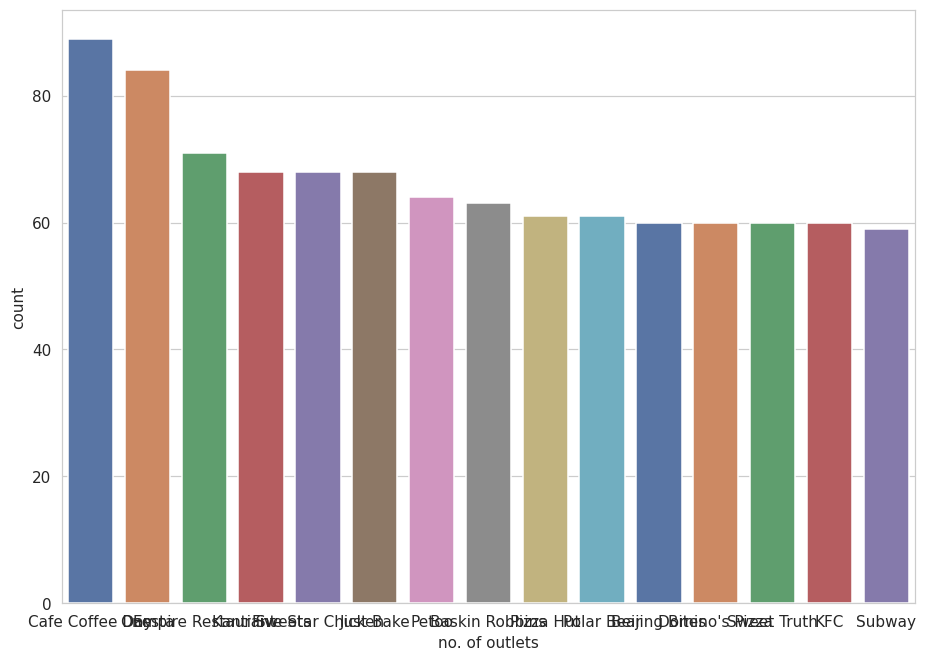

In [296]:
plt.figure(figsize=(10,7),dpi=110)

chains = data['name'].value_counts()[0:15]

sns.barplot(x=chains.index,y=chains,palette='deep')
plt.xlabel("no. of outlets")

plt.show()

These are the top resturant chains...'cafe coffee day' being at the top


## how many restaurants don't accept online orders

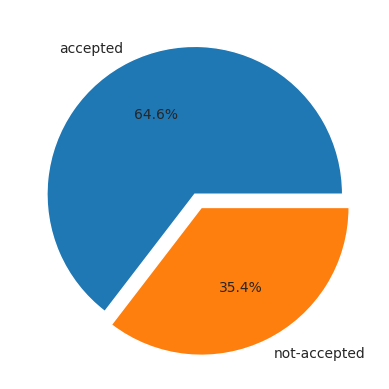

In [297]:
x = data.online_order.value_counts()
labels = ['accepted','not-accepted']
plt.pie(x,labels=labels,explode=[0.0,0.1],autopct='%1.1f%%')

plt.show()

we see that around 66.9% of resturants accept online orders

## How many resturants had TABLE BOOKINGS?

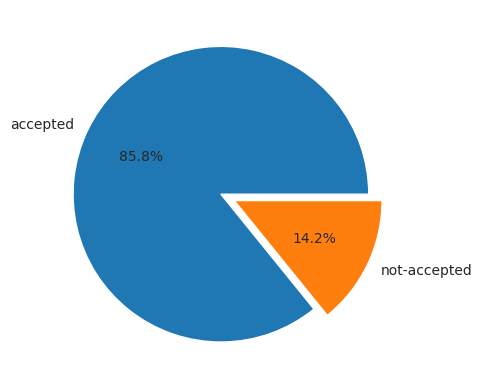

In [298]:
x = data.book_table.value_counts()
labels = ['accepted','not-accepted']
plt.pie(x,labels=labels,explode=[0.0,0.1],autopct='%1.1f%%')

plt.show()

we observe that around 85.8% resturants have table bookings.

## analysis on type of restaurants

In [299]:
data.head(5)

,name,online_order,book_table,rate,votes,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ..."
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din..."
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ..."
3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper..."
4,Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ..."


In [300]:
data.rest_type.unique()

array(['Casual Dining', 'Cafe, Casual Dining', 'Quick Bites',
       'Casual Dining, Cafe', 'Cafe', 'Quick Bites, Cafe',
       'Cafe, Quick Bites', 'Delivery', 'Mess', 'Dessert Parlor',
       'Bakery, Dessert Parlor', 'Pub', 'Bakery', 'Takeaway, Delivery',
       'Fine Dining', 'Beverage Shop', 'Sweet Shop', 'Bar',
       'Dessert Parlor, Sweet Shop', 'Bakery, Quick Bites',
       'Sweet Shop, Quick Bites', 'Kiosk', 'Food Truck',
       'Quick Bites, Dessert Parlor', 'Beverage Shop, Quick Bites',
       'Beverage Shop, Dessert Parlor', 'Takeaway', 'Pub, Casual Dining',
       'Casual Dining, Bar', 'Dessert Parlor, Beverage Shop',
       'Quick Bites, Bakery', 'Microbrewery, Casual Dining', 'Lounge',
       'Bar, Casual Dining', 'Food Court', 'Cafe, Bakery', nan, 'Dhaba',
       'Quick Bites, Sweet Shop', 'Microbrewery',
       'Food Court, Quick Bites', 'Quick Bites, Beverage Shop',
       'Pub, Bar', 'Casual Dining, Pub', 'Lounge, Bar',
       'Dessert Parlor, Quick Bites', 'Food Co

In [301]:
len(data.rest_type.unique())

88

In [302]:
data.rest_type.value_counts()

,count
rest_type,
Quick Bites,15042
Casual Dining,9802
Cafe,3466
Dessert Parlor,1929
Delivery,1780
...,...
"Bakery, Food Court",2
"Bakery, Beverage Shop",2
"Food Court, Beverage Shop",2


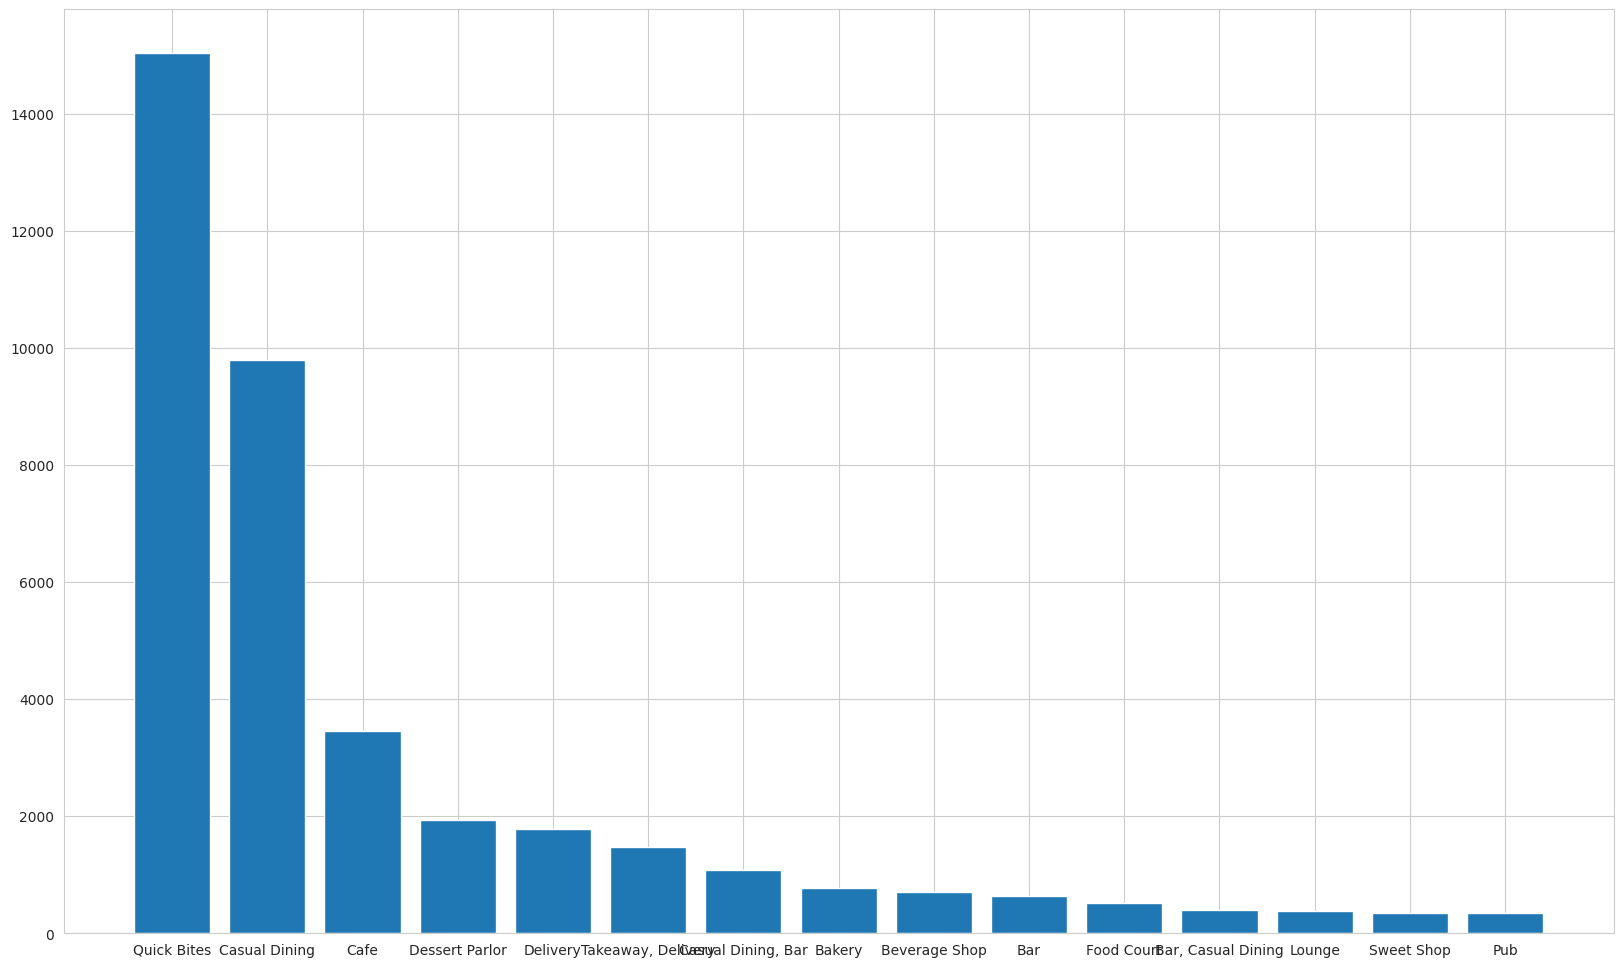

In [303]:
plt.figure(figsize=(20,12))
rest_typ = data.rest_type.value_counts()[0:15]
plt.bar(rest_typ.index,rest_typ)

plt.show()




This is the distribution of type of resturants and we observe that Quick bites at the top...further this is the dataset of banglore city
so most of the people living there prefer quick bites(fast food chains)

## which restaurant had the highest voting? (means count of rating given)

In [304]:
data.head()

,name,online_order,book_table,rate,votes,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ..."
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din..."
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ..."
3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper..."
4,Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ..."


In [305]:
voting = data.groupby('name')[['votes']].mean()
voting

,votes
name,
#FeelTheROLL,7.000000
#L-81 Cafe,48.000000
#refuel,37.000000
1000 B.C,49.000000
100ÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂ°C,41.000000
...,...
i-Bar - The Park Bangalore,619.727273
iFruit Live Ice Creams,10.000000
iSpice Resto Cafe,30.142857


In [306]:
voting['votes'].describe()

,votes
count,7153.000000
mean,198.850898
std,597.717530
min,0.000000
25%,10.266667
50%,38.000000
75%,145.500000
max,16507.333333


In [307]:
high_vot = voting[voting['votes'] >5000]

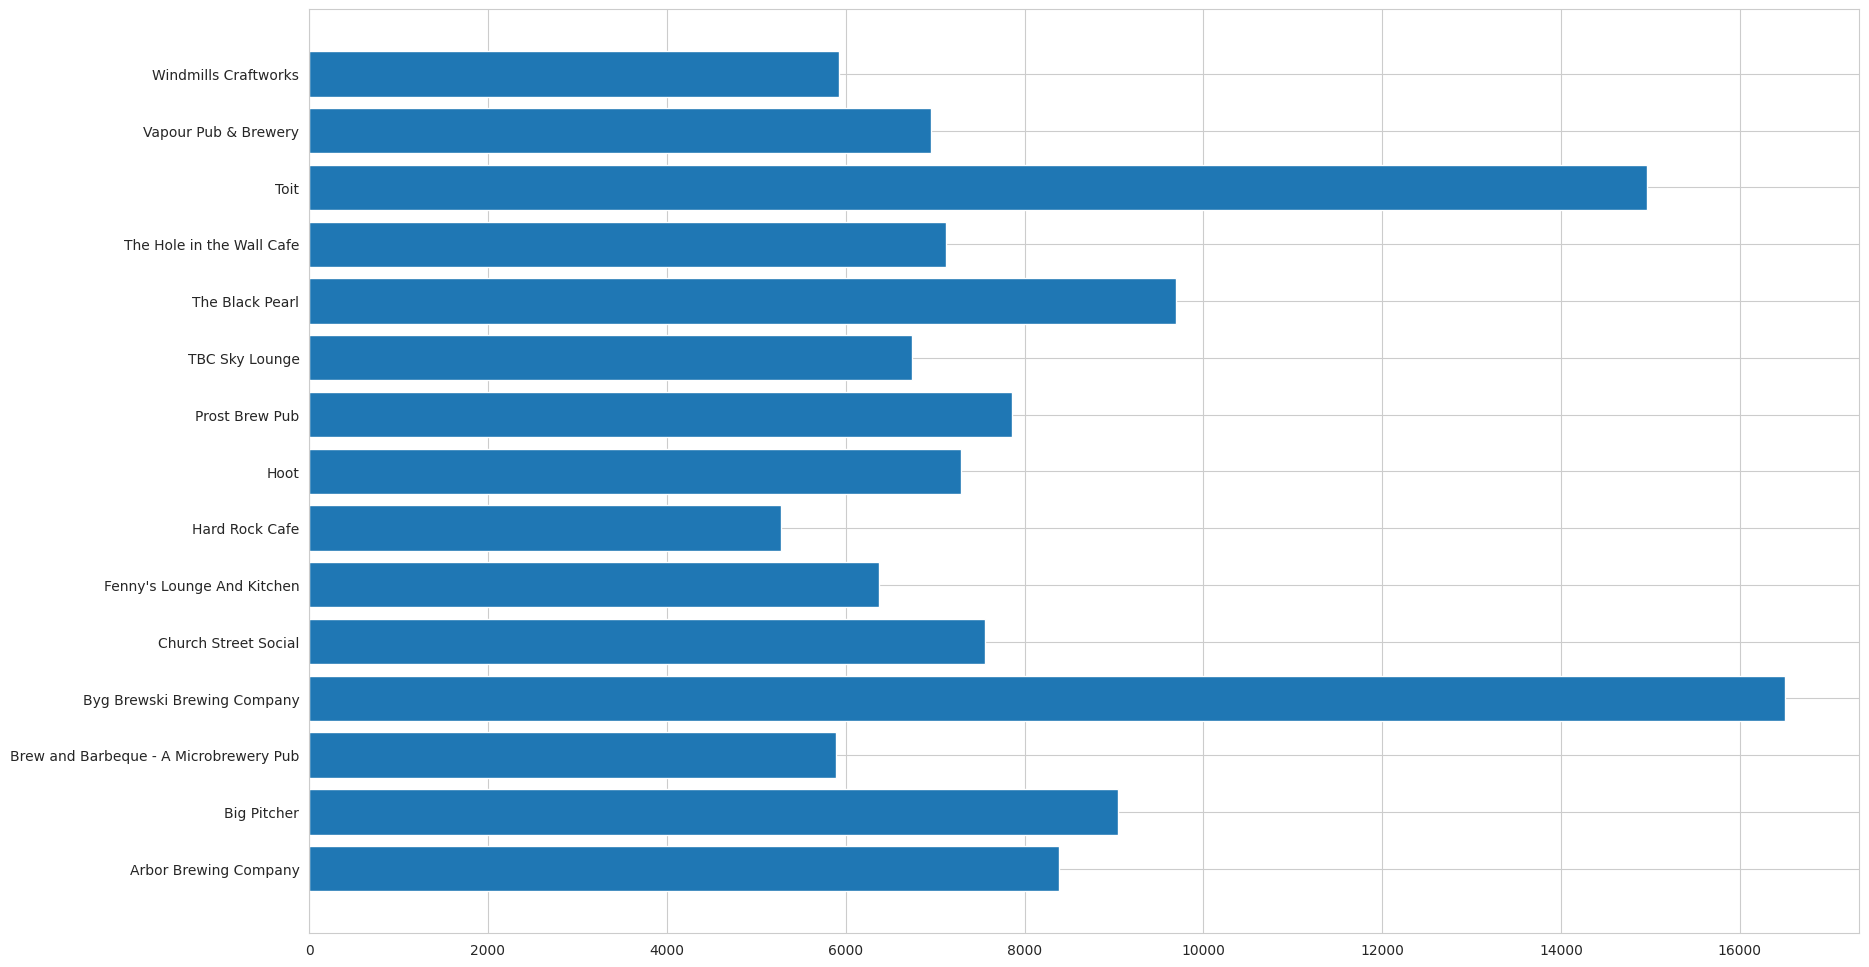

In [308]:
plt.figure(figsize=(20,12),dpi=100)

plt.barh(high_vot.index,high_vot['votes'])

plt.show()

This is the barplot for count of ratings given by consumers to a particular resturant

### Let's analyse the highly rated restaurants and worst restaurants based on number of ratings given

In [309]:
data.head(3)

,name,online_order,book_table,rate,votes,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ..."
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din..."
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ..."


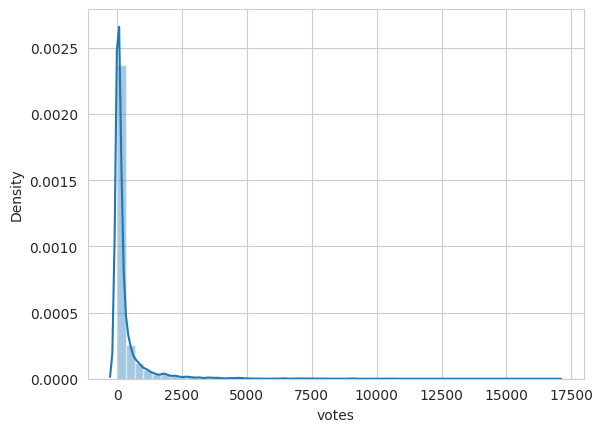

In [310]:
sns.distplot(data['votes'])

plt.show()

In [311]:
voting_rating = data.groupby('name')[['votes']].mean().sort_values('votes',ascending=False)
voting_rating

,votes
name,
Byg Brewski Brewing Company,16507.333333
Toit,14956.000000
The Black Pearl,9690.769231
Big Pitcher,9041.000000
Arbor Brewing Company,8385.000000
...,...
Mawa and Co,0.000000
Mayur Veg Restaurant,0.000000
Maruti Garden,0.000000


In [312]:
voting_rating['name'] = voting_rating.index

In [313]:
voting_rating = voting_rating.reset_index(drop=True)

voting_rating.head()

,votes,name
0,16507.333333,Byg Brewski Brewing Company
1,14956.000000,Toit
2,9690.769231,The Black Pearl
3,9041.000000,Big Pitcher
4,8385.000000,Arbor Brewing Company


In [314]:
voting_rating = pd.merge(voting_rating,data[['rate','name']])
voting_rating

,votes,name,rate
0,16507.333333,Byg Brewski Brewing Company,4.9
1,16507.333333,Byg Brewski Brewing Company,4.9
2,16507.333333,Byg Brewski Brewing Company,4.9
3,14956.000000,Toit,4.7
4,9690.769231,The Black Pearl,4.8
...,...,...,...
43375,0.000000,The Food Therapy,0.0
43376,0.000000,The Food Therapy,0.0
43377,0.000000,The Food Therapy,0.0
43378,0.000000,The Food Therapy,0.0


In [315]:
vote_top = voting_rating[voting_rating['votes'] > 5000]
vote_top.head()

,votes,name,rate
0,16507.333333,Byg Brewski Brewing Company,4.9
1,16507.333333,Byg Brewski Brewing Company,4.9
2,16507.333333,Byg Brewski Brewing Company,4.9
3,14956.000000,Toit,4.7
4,9690.769231,The Black Pearl,4.8


In [316]:
vote_top = vote_top.groupby('name')[['rate']].mean().sort_values('rate',ascending=False)
vote_top

,rate
name,
Byg Brewski Brewing Company,4.900000
The Black Pearl,4.723077
Big Pitcher,4.700000
TBC Sky Lounge,4.700000
Toit,4.700000
The Hole in the Wall Cafe,4.600000
Brew and Barbeque - A Microbrewery Pub,4.600000
Windmills Craftworks,4.600000
Fenny's Lounge And Kitchen,4.521429


### highest Rated based on most number of votes

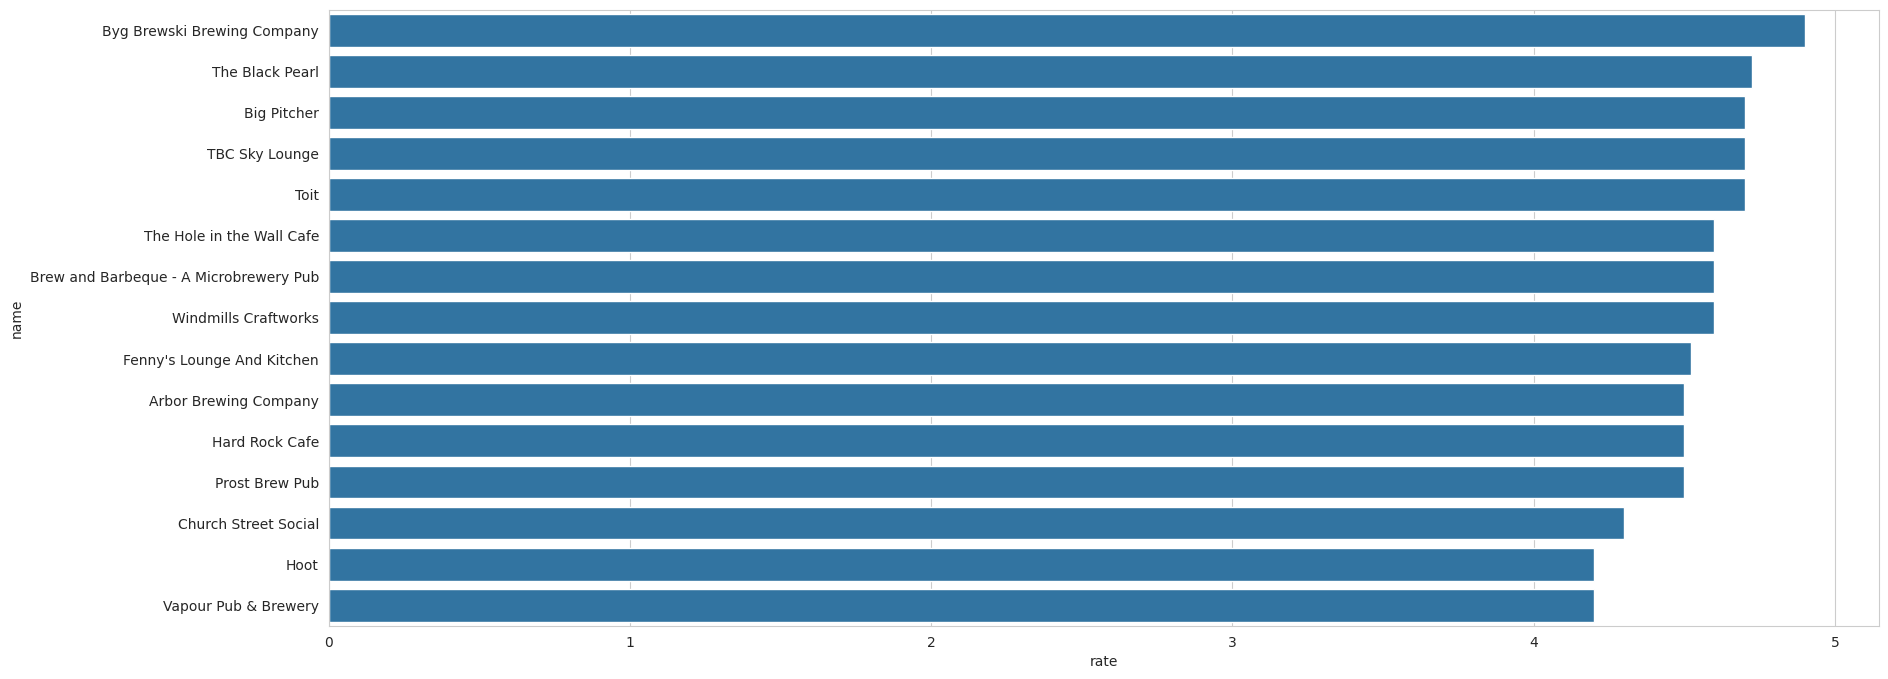

In [317]:
plt.figure(figsize=(20,8),dpi=100)

sns.barplot(x=vote_top['rate'],y=vote_top.index,orient='h')

plt.show()

'Byg Brewski Brewing Company' is the most voted resturant with the average rating of 4.9

In [318]:
bad_count = voting_rating[(voting_rating['rate'] < 3) & (voting_rating['rate'] > 0)]
bad_count

,votes,name,rate
3399,967.681818,Kritunga Restaurant,2.6
3400,967.681818,Kritunga Restaurant,2.9
3401,967.681818,Kritunga Restaurant,2.9
3416,967.681818,Kritunga Restaurant,2.7
3417,967.681818,Kritunga Restaurant,2.7
...,...,...,...
41246,4.000000,NTR Cafe,2.9
41247,4.000000,NTR Cafe,2.9
41409,4.000000,Sandesh Restaurant,2.9
41747,2.500000,Kushi Meals,2.8


In [319]:
bad_resturants = bad_count[bad_count['votes'] > 500].groupby('name')[['rate']].mean()
bad_resturants

,rate
name,
Anjappar,2.833333
FreshMenu,2.800000
Kabab Magic,2.900000
Kritunga Restaurant,2.760000
Lakeview Milkbar,2.900000
Lazeez,2.600000
Moriz Restaurant,2.775000
Savoury Restaurant,2.900000
Smoke - The Sizzler House,2.800000


### worst restaurants based on highest number of votes given

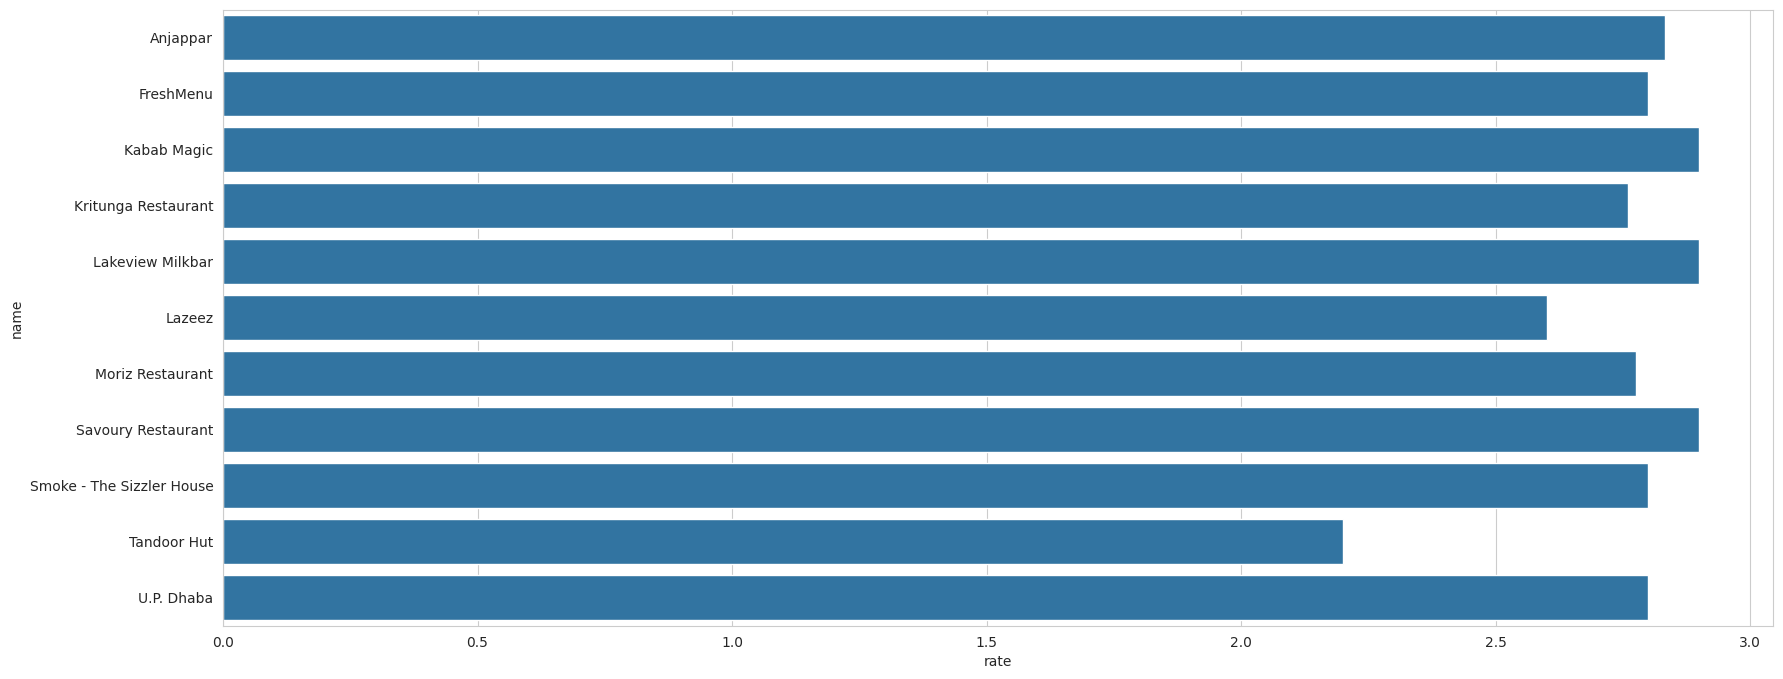

In [320]:
plt.figure(figsize=(20,8))

sns.barplot(x=bad_resturants['rate'], y=bad_resturants.index)

plt.show()

These resturants have good votes given by the consumer but less rating..which means there is something wrong with these resturants

# location in which we have highest number of restaurants

In [250]:
data.head()

,name,online_order,book_table,rate,votes,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ..."
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din..."
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ..."
3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper..."
4,Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ..."


In [251]:
location_restro = data[['location']].value_counts()[0:20]
location_restro

,count
location,
BTM,4251
Koramangala 5th Block,2284
HSR,2112
Indiranagar,1893
JP Nagar,1839
Jayanagar,1711
Whitefield,1676
Marathahalli,1474
Bannerghatta Road,1316


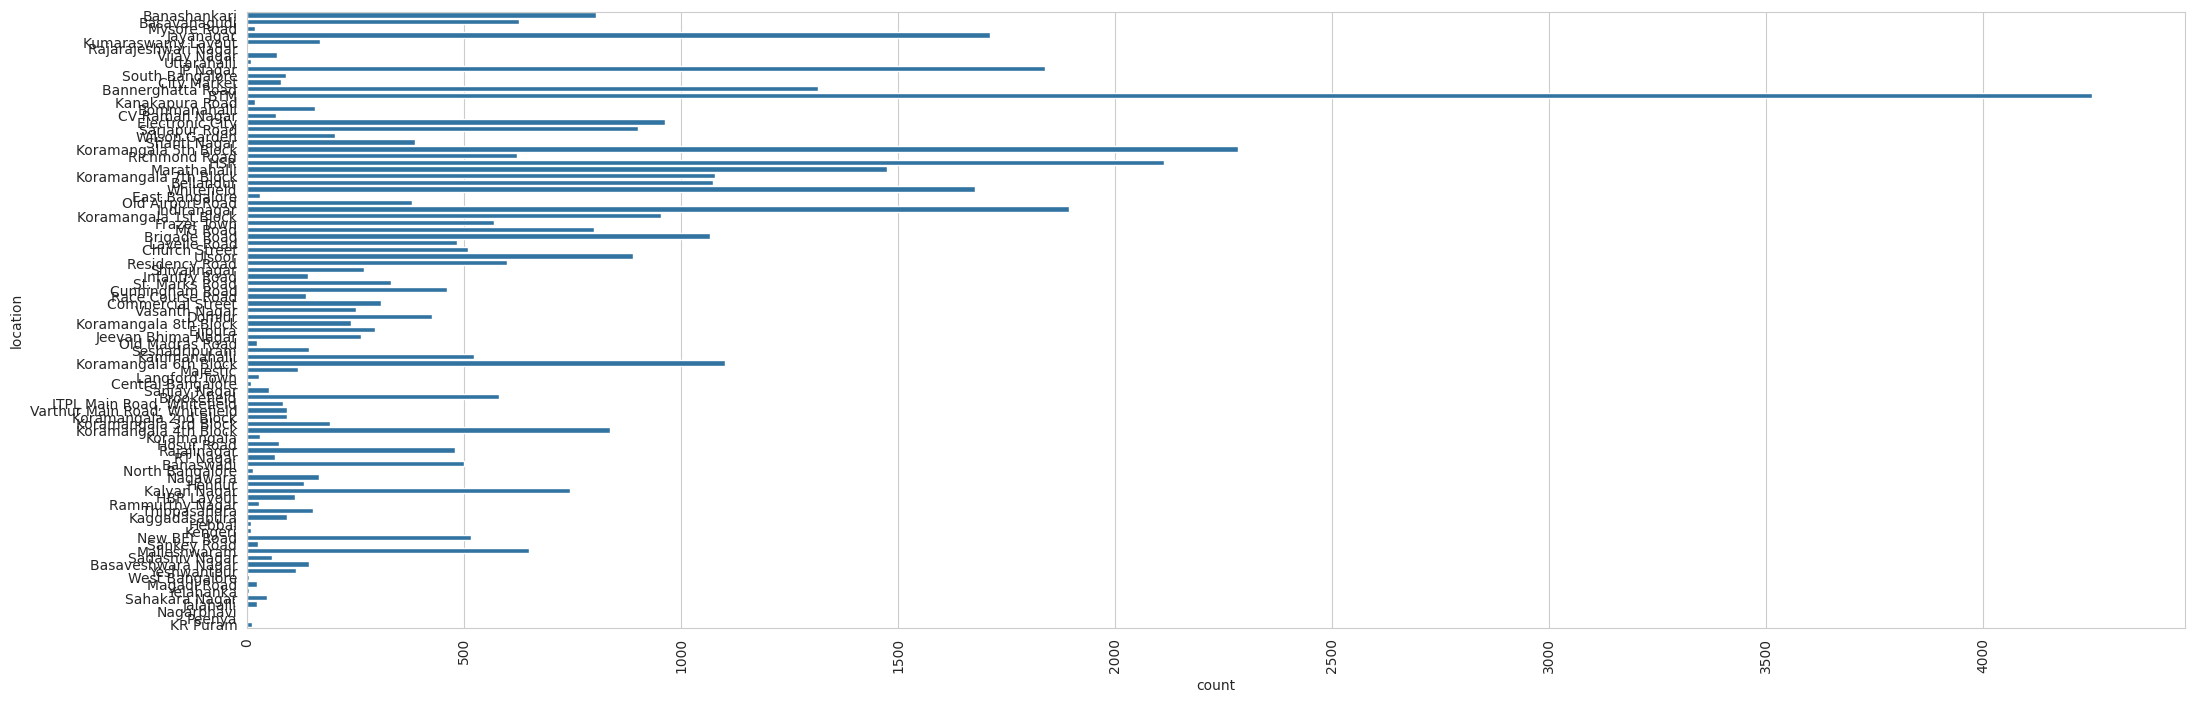

In [252]:
plt.figure(figsize=(25,8))
sns.countplot(data['location'])

plt.xticks(rotation=90)

plt.show()

Barplot of number of resturants in any location

# Identify the top 10 cuisines

In [253]:
data.head()

,name,online_order,book_table,rate,votes,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ..."
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din..."
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ..."
3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper..."
4,Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ..."


In [254]:
data.rest_type.value_counts()

,count
rest_type,
Quick Bites,15042
Casual Dining,9802
Cafe,3466
Dessert Parlor,1929
Delivery,1780
...,...
"Bakery, Food Court",2
"Bakery, Beverage Shop",2
"Food Court, Beverage Shop",2


cuisines
North Indian                           2271
North Indian, Chinese                  2045
South Indian                           1317
Cafe                                    653
Bakery, Desserts                        643
Biryani                                 640
South Indian, North Indian, Chinese     601
Fast Food                               580
Desserts                                570
Chinese                                 449
Name: count, dtype: int64


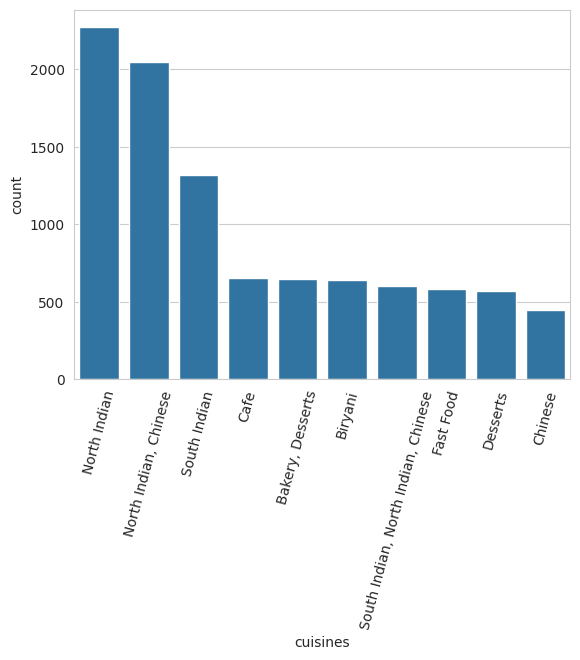

In [255]:
cusin = data.cuisines.value_counts()[0:10]
print(cusin)
sns.barplot(x=cusin.index, y=cusin)
plt.xticks(rotation=75)
plt.show()

Barplot of top 10 cuisines preffered by customers

### Check the distribution for cost of 2 people

In [256]:
data['approx_cost(for two people)'].isna().sum()

np.int64(250)

In [257]:
data.dropna(axis=0,subset=['approx_cost(for two people)'],inplace=True)

In [258]:
data['approx_cost(for two people)']

,approx_cost(for two people)
0,800
1,800
2,800
3,300
4,600
...,...
51147,800
51149,800
51150,"1,500"
51153,"2,500"


In [259]:
data['approx_cost(for two people)'] = data['approx_cost(for two people)'].apply(lambda x: x.replace(',',''))

In [260]:
data['approx_cost(for two people)']

,approx_cost(for two people)
0,800
1,800
2,800
3,300
4,600
...,...
51147,800
51149,800
51150,1500
51153,2500


In [261]:
data['approx_cost(for two people)'] = data['approx_cost(for two people)'].astype(int)

In [262]:
data['approx_cost(for two people)']

,approx_cost(for two people)
0,800
1,800
2,800
3,300
4,600
...,...
51147,800
51149,800
51150,1500
51153,2500


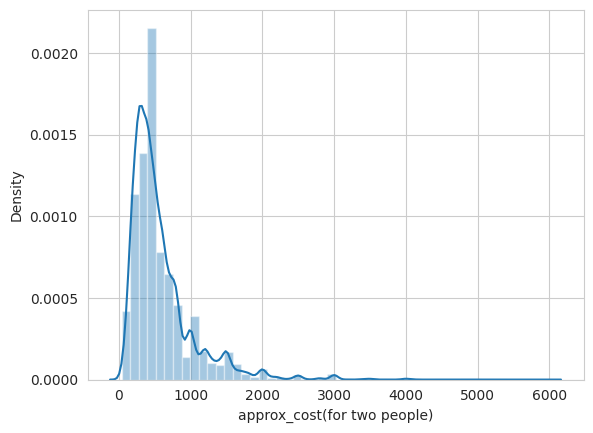

In [263]:
sns.distplot(data['approx_cost(for two people)'])



plt.show()

In [264]:
data['approx_cost(for two people)'].describe()

,approx_cost(for two people)
count,43130.000000
mean,587.670206
std,454.366401
min,40.000000
25%,300.000000
50%,450.000000
75%,700.000000
max,6000.000000


In [265]:
data[data['approx_cost(for two people)'] > 2000]

,name,online_order,book_table,rate,votes,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list
3307,Beetle Juice Bar - Springs Hotel & Spa,No,Yes,3.7,64,Basavanagudi,Bar,Rooftop Ambience,Finger Food,2200,[]
3733,Beetle Juice Bar - Springs Hotel & Spa,No,Yes,3.7,64,Basavanagudi,Bar,Rooftop Ambience,Finger Food,2200,[]
4811,The Square - Novotel,No,Yes,4.3,760,Marathahalli,Fine Dining,"Breakfast Buffet, Cocktails, Sunday Brunch, No...","Continental, North Indian, Japanese, Italian",2500,"[('Rated 5.0', 'RATED\n Christmas always used..."
4852,Chez Nous - Novotel,No,Yes,3.9,125,Marathahalli,Lounge,"Coffee, Cocktails, Tiramisu, Cappuccino, Hot C...","European, French, North Indian",2500,"[('Rated 5.0', 'RATED\n I will visit there la..."
4942,Chez Nous - Novotel,No,Yes,3.9,125,Marathahalli,Lounge,"Coffee, Cocktails, Tiramisu, Cappuccino, Hot C...","European, French, North Indian",2500,"[('Rated 5.0', 'RATED\n I will visit there la..."
...,...,...,...,...,...,...,...,...,...,...,...
51091,Windmills Craftworks,No,No,4.6,5954,Whitefield,"Microbrewery, Pub","Keema Pav, Cocktails, Craft Beer, Pork Chops, ...","American, North Indian, Salad",2500,"[('Rated 5.0', ""RATED\n A review for Windmill..."
51106,Bling - The Zuri,No,No,3.7,228,Whitefield,Lounge,"Martini, Cocktails, Paneer Tikka","Continental, North Indian",2100,"[('Rated 3.0', 'RATED\n Happen to visit there..."
51121,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,Yes,4.3,236,"ITPL Main Road, Whitefield",Bar,"Cocktails, Pizza, Buttermilk",Finger Food,2500,"[('Rated 4.0', 'RATED\n Nice and friendly pla..."
51125,Windmills Craftworks,No,No,4.6,5954,Whitefield,"Microbrewery, Pub","Keema Pav, Cocktails, Craft Beer, Pork Chops, ...","American, North Indian, Salad",2500,"[('Rated 5.0', ""RATED\n A review for Windmill..."


Distibution of cost for 2 people in resturants most of the resurants costs below Rs.1000

# Conclusions:

1. Asia Kitchen By Mainland China,Spa Cuisine,Byg Brewski Brewing Company,Punjab Grill	were the best rated Restaurants.

2. Cafe Coffee Day, Onesta, Empire Restaurant, Just Bake ,Kanti sweets were the top restaurant chains.
           
3. 64.4% of resturants accept online orders where as 35.6% donot accept online orders.

4. Based on most voted resaturants Byg Brewski Brewing Company and The Black Pearl	were the best rated restaurants.

5. Based on most voted resaturants Lazeez and Tandoor Hut were the worst rated restaurants.

6. BTM, Koramangala 5th Block has the most numbers of restaurants.

7. North Indian and Chinese were the top favourite of the people in Bangalore.

8. Cost for 2 people for most restaurants was varing from 500 to 1000 bucks.

# Question

Question:

Describe a function that takes 3 parameters: cost for 2 people, location and Restaurant type and return the name of resturants available at that location.

Comment below the names of restaurants that fall in Whitefield for casual dining and have cost below Rs.1000?


In [323]:
def return_budget(location, restaurant_type, max_cost):

    # Create a temporary copy to avoid modifying the global DataFrame in place if not intended
    df_filtered = data.copy()

    # Ensure the 'approx_cost(for two people)' column is numeric within this function scope
    # Re-apply cleaning steps to handle potential state issues if the column is still string
    df_filtered['approx_cost(for two people)'] = df_filtered['approx_cost(for two people)'].astype(str).str.replace(',', '', regex=False)
    df_filtered['approx_cost(for two people)'] = pd.to_numeric(df_filtered['approx_cost(for two people)'], errors='coerce')
    df_filtered.dropna(subset=['approx_cost(for two people)'], inplace=True) # Handle rows where conversion might result in NaN

    filtered_restaurants = df_filtered[
        (df_filtered['approx_cost(for two people)'] <= max_cost) &
        (df_filtered['location'] == location) &
        (df_filtered['rest_type'] == restaurant_type) &
        (df_filtered['rate'] > 4) # Added a filter for good ratings (rate > 4)
    ]
    return filtered_restaurants['name'].unique()

In [324]:
# Get the names of restaurants in Whitefield for Casual Dining with cost below Rs. 1000
whitefield_casual_dining_below_1000 = return_budget('Whitefield', 'Casual Dining', 1000)

print("Restaurants in Whitefield for Casual Dining with cost below Rs.1000 (and rate > 4):")
for restaurant in whitefield_casual_dining_below_1000:
    print(f"- {restaurant}")

Restaurants in Whitefield for Casual Dining with cost below Rs.1000 (and rate > 4):
- The Square Table
- Galito's
- Suryawanshi
- NH8
- Kapoor's Cafe
- Salt Mango Tree
- Imperio Restaurant
- Nasi And Mee
- Sorse
- Chez Mariannick
